In [4]:
import pathlib
from dotenv import load_dotenv
import os

from langchain import hub
from langchain_openai import ChatOpenAI, OpenAIEmbeddings, OpenAI
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import JSONLoader
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import START, StateGraph
from langchain_core.prompts import PromptTemplate

In [2]:
load_dotenv("../.env")
if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

In [11]:
llm = OpenAI(model="qwen2.5-14b-instruct-1m", 
             base_url="http://127.0.0.1:11434",
             api_key="lm-studio")
# embeddings = OpenAIEmbeddings(model="deepseek-r1-distill-llama-70b")

In [31]:
# Make sure to `pip install openai` first
from openai import OpenAI
client = OpenAI(base_url="http://127.0.0.1:11434", api_key="lm-studio")

def get_embedding(text, model="qwen2.5-14b-instruct-1m"):
   text = text.replace("\n", " ")
   return client.embeddings.create(input = [text], model=model).data[0].embedding

print(get_embedding("Once upon a time, there was a cat."))


TypeError: 'NoneType' object is not iterable

In [29]:
input_text = "The meaning of life is 42"
vector = embeddings.embed_query(input_text)
print(vector[:3])

TypeError: 'NoneType' object is not iterable

In [10]:
!pip install llama-cpp-python

     ---------------------------------------- 0.0/66.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/66.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/66.9 MB ? eta -:--:--
     ---------------------------------------- 0.3/66.9 MB ? eta -:--:--
     ---------------------------------------- 0.3/66.9 MB ? eta -:--:--
     --------------------------------------- 0.5/66.9 MB 645.7 kB/s eta 0:01:43
     --------------------------------------- 0.8/66.9 MB 699.0 kB/s eta 0:01:35
     --------------------------------------- 0.8/66.9 MB 699.0 kB/s eta 0:01:35
      -------------------------------------- 1.0/66.9 MB 719.5 kB/s eta 0:01:32
      -------------------------------------- 1.0/66.9 MB 719.5 kB/s eta 0:01:32
      -------------------------------------- 1.3/66.9 MB 729.7 kB/s eta 0:01:30
      -------------------------------------- 1.6/66.9 MB 769.7 kB/s eta 0:01:25
     - ------------------------------------- 1.8/66.9 MB 762.8 kB/s eta 0:01:26


  error: subprocess-exited-with-error
  
  × Building wheel for llama-cpp-python (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      *** scikit-build-core 0.10.7 using CMake 3.31.4 (wheel)
      *** Configuring CMake...
      2025-01-27 11:27:36,730 - scikit_build_core - WARNING - Can't find a Python library, got libdir=None, ldlibrary=None, multiarch=None, masd=None
      loading initial cache file C:\Users\R1\AppData\Local\Temp\tmpximsvsuj\build\CMakeInit.txt
      -- Building for: NMake Makefiles
      CMake Error at CMakeLists.txt:3 (project):
        Running
      
         'nmake' '-?'
      
        failed with:
      
         no such file or directory
      
      
      CMake Error: CMAKE_C_COMPILER not set, after EnableLanguage
      CMake Error: CMAKE_CXX_COMPILER not set, after EnableLanguage
      -- Configuring incomplete, errors occurred!
      
      *** CMake configuration failed
      [end of output]
  
  note: This error orig

In [9]:
from langchain_community.embeddings import LlamaCppEmbeddings

embeddings = LlamaCppEmbeddings(model_path="C:/Users/R1/.lmstudio/models/lmstudio-community/Qwen2.5-14B-Instruct-1M-GGUF/Qwen2.5-14B-Instruct-1M-Q8_0.gguf")

ImportError: Could not import llama-cpp-python library. Please install the llama-cpp-python library to use this embedding model: pip install llama-cpp-python

In [6]:
path_to_faiss = pathlib.Path(r"C:\Users\vallo\Documents\Projects\News-Assistant-AI\data\index\faiss_index").as_posix()
if not os.path.isdir(path_to_faiss):
    path_to_faiss = input("Enter path to faiss or pass")
    if path_to_faiss is not None:
        path_to_faiss = pathlib.Path(path_to_faiss).as_posix()
        assert os.path.isdir(path_to_faiss), "path is not valid!"

In [7]:
faiss_store = FAISS.load_local(
        path_to_faiss, 
        embeddings, 
        allow_dangerous_deserialization=True
    )

NameError: name 'embeddings' is not defined

In [170]:
def metadata_func(record: dict, metadata: dict) -> dict:

    metadata["datetime"] = record.get("datetime")
    metadata["link"] = record.get("link")

    return metadata

json_file_path = pathlib.Path(r"C:\Users\R1\Documents\Projects\News-Assistant-AI\data\raw\combined_news.json").as_posix()
loader = JSONLoader(
        file_path = json_file_path,
        jq_schema='.[]',
        content_key="text",
        metadata_func=metadata_func
    )
data = loader.load() 

In [67]:
text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=200,
        chunk_overlap=20,
        is_separator_regex=False,
    )
texts = text_splitter.split_documents(data)

In [68]:
document_ids = faiss_store.add_documents(documents=texts) # Индексируем чанки

In [190]:
# Определяем свой промпт

template = """You are a news-assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, say that you don't know.
Use three sentences maximum and keep the answer concise.


{context}

Question: {question}

Helpful Answer:"""
custom_rag_prompt = PromptTemplate.from_template(template)

In [216]:
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [222]:
def retrieve(state: State):
    # retrieved_docs = faiss_store.similarity_search(state["question"])
    faiss_retriever = faiss_store.as_retriever(k=5)
    retrieved_docs = faiss_retriever.get_relevant_documents(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = custom_rag_prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [223]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

In [241]:
result = graph.invoke({"question": "Танки Abrams"})

In [242]:
answer = result["answer"]

links = set()
for doc in result["context"]:
    links.add(doc.metadata["link"])

In [245]:
answer, links

('Танки Abrams используются Вооруженными силами Украины (ВСУ) в боях, согласно информации от замначальника штаба по разведке приморского добровольческого отряда "Тигр". Эти танки являются частью западной военной помощи.',
 {'https://t.me/rian_ru/270250', 'https://t.me/rian_ru/271010'})

---

In [ ]:
def main():
    

---

In [3]:
path_to_faiss = pathlib.Path(r"C:\Users\vallo\Documents\Projects\News-Assistant-AI\data\index\faiss_index").as_posix()


In [4]:
import os

os.path.isdir(path_to_faiss)

True

In [2]:
# %pip install -U langchain sentence_transformers langchain_huggingface langchain_community unstructured nltk==3.9.1
# %pip install -U jq pypdf langchain_chroma rank_bm25 arxiv langchain_openai scikit-learn
# %pip install -U langchain-community faiss-cpu langgraph

In [112]:
import json
import os

from pathlib import Path
import json
from IPython.display import Image, display

from langchain_community.document_loaders import JSONLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain.embeddings import OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langchain_core.messages import SystemMessage
from langgraph.graph import END, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.documents import Document
from langchain_core.tools import tool

from typing import List

In [11]:
from dotenv import load_dotenv

load_dotenv("../.env")



True

In [4]:
# Define the metadata extraction function.
def metadata_func(record: dict, metadata: dict) -> dict:

    metadata["datetime"] = record.get("datetime")
    metadata["link"] = record.get("link")

    return metadata

def refresh_index(json_file_path):
    assert os.path.isfile(json_file_path), "File is not exists!"
    loader = JSONLoader(
        file_path = json_file_path,
        jq_schema='.[]',
        content_key="text",
        metadata_func=metadata_func
    )
    data = loader.load() 
    # Разделение документов на фрагменты для улучшения поиска
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=200,
        chunk_overlap=20,
        is_separator_regex=False,
    )
    texts = text_splitter.split_documents(data)
    return texts

In [5]:
from dotenv import load_dotenv

load_dotenv("../.env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [6]:
def set_faiss_retriever(is_indexed: bool = True,
              path_to_faiss: str = "../data/index/faiss_index",
              texts: list = None):
    """Set faiss

    Args:
        is_indexed (bool, optional): if you have indexed faiss-store. Defaults to True.
        path_to_faiss (str, optional): path to your store. Defaults to "../data/index/faiss_index".
        texts (list, optional): list with Documents to refresh faiss. Defaults to None.
    """
    api_key = os.getenv("GPT_TOKEN")
    embeddings = OpenAIEmbeddings(api_key=api_key)
    if not is_indexed:
        assert texts is not None, "Put your texts with Document"
        faiss_store = FAISS.from_documents(texts, embeddings)
        faiss_store.save_local(path_to_faiss)
    # assert os.path.isdir(path_to_faiss), "FAISS is not created!"
    faiss_store = FAISS.load_local(
        path_to_faiss, embeddings, allow_dangerous_deserialization=True
    )
    global faiss_retriever
    faiss_retriever = faiss_store.as_retriever(k=5)
    return faiss_retriever

In [7]:
FAISS_STORE = "../data/index/faiss_index"

In [9]:
faiss_retriever = set_faiss_retriever(path_to_faiss=FAISS_STORE)

ValidationError: 1 validation error for OpenAIEmbeddings
  Value error, Did not find openai_api_key, please add an environment variable `OPENAI_API_KEY` which contains it, or pass `openai_api_key` as a named parameter. [type=value_error, input_value={'model_kwargs': {}, 'cli...20, 'http_client': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.9/v/value_error

In [9]:
# texts = refresh_index(pathlib.Path(r"C:\Users\R1\Documents\Projects\News-Assistant-AI\data\raw\combined_news.json").as_posix())
# embeddings = OpenAIEmbeddings(api_key=OPENAI_API_KEY)
# # faiss_store = FAISS.load_local(
# #     FAISS_STORE, embeddings, allow_dangerous_deserialization=True
# # )
# faiss_store = FAISS.from_documents(texts, embeddings)

In [10]:
# faiss_store.save_local(FAISS_STORE)

# faiss_store = FAISS.load_local(
#     FAISS_STORE, embeddings, allow_dangerous_deserialization=True
# )

In [11]:
# faiss_retriever = faiss_store.as_retriever(k=5)

In [12]:
# answers = faiss_retriever.invoke("новости из зоопарка")
# for answer in answers:
#   print(answer)
#   print()

In [13]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=OPENAI_API_KEY)

---

In [113]:
@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """Retrieve information related to a query."""
    retrieved_docs = faiss_retriever.get_relevant_documents(query, k=5)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

In [111]:
class State(MessagesState):
    context: List[Document]


# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: State):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"])
    # MessagesState appends messages to state instead of overwriting
    return {"messages": [response]}


# Step 2: Execute the retrieval.
tools = ToolNode([retrieve])


# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    context = []
    for tool_message in tool_messages:
        context.extend(tool_message.artifact)
    return {"messages": [response], "context": context}

NameError: name 'MessagesState' is not defined

In [16]:
def compile_graph():
    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node(query_or_respond)
    graph_builder.add_node(tools)
    graph_builder.add_node(generate)

    graph_builder.set_entry_point("query_or_respond")
    graph_builder.add_conditional_edges(
        "query_or_respond",
        tools_condition,
        {END: END, "tools": "tools"},
    )
    graph_builder.add_edge("tools", "generate")
    graph_builder.add_edge("generate", END)

    graph = graph_builder.compile()
    return graph

In [25]:
graph_builder = StateGraph(MessagesState)

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

In [31]:
graph = compile_graph()

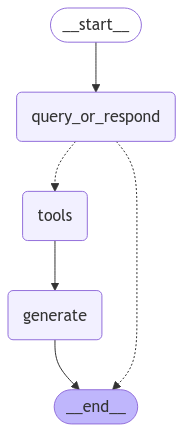

In [32]:
graph

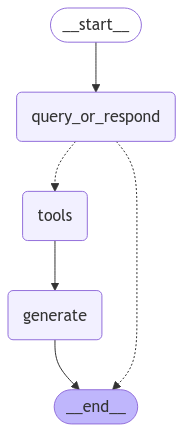

In [30]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
input_message = 'Расскажите новости про Трампа'

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    pass

C:\Users\R1\AppData\Local\Temp\ipykernel_24068\1834145543.py:4: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = faiss_retriever.get_relevant_documents(query, k=5)


In [28]:
result = {
    "answer" : step["messages"][-1].content,
    "links" : [link.metadata["link"] for link in step["context"]]
    }

In [29]:
result

{'answer': 'Трамп был поздравлен с избранием на пост президента США, что отметил Путин. Лукашенко также назвал Трампа победителем на выборах в США. Кроме того, Трамп поздравил Вэнса с назначением на должность вице-президента США.',
 'links': ['https://t.me/rian_ru/268826',
  'https://t.me/rian_ru/268067',
  'https://t.me/rian_ru/268064',
  'https://t.me/rian_ru/267785',
  'https://t.me/rian_ru/267793']}